In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import os


# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
import joblib

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, Reshape
from tensorflow.keras.callbacks import EarlyStopping


In [3]:

# --- Configuration ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

MODEL_SAVE_PATH = "trained_models_csv"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

In [4]:
# --- 1. Load and Understand Data ---
print("--- Loading Data ---")
# Assuming your CSVs are in the current directory or provide full paths
try:
    df_http = pd.read_csv("normal_http.csv")
    df_tcp = pd.read_csv("normal_tcp.csv")
    df_udp = pd.read_csv("normal_udp.csv")
    # It's crucial to know if these also contain attack data or if attack data is separate.
    # For now, I'll assume 'attack_mode' column distinguishes normal from attack in all files.
    # If you have separate attack CSVs, load and concatenate them here.
    # Example: df_attack1 = pd.read_csv("dos_attack.csv")
    #          df_attack2 = pd.read_csv("ddos_attack.csv")
    #          df = pd.concat([df_http, df_tcp, df_udp, df_attack1, df_attack2], ignore_index=True)

    df_list = []
    if 'df_http' in locals() and not df_http.empty: df_list.append(df_http)
    if 'df_tcp' in locals() and not df_tcp.empty: df_list.append(df_tcp)
    if 'df_udp' in locals() and not df_udp.empty: df_list.append(df_udp)

    if not df_list:
        raise FileNotFoundError("No data files found or files are empty. Please check paths.")

    df_original = pd.concat(df_list, ignore_index=True)
    print(f"Total rows loaded: {len(df_original)}")
    print(f"Total columns: {len(df_original.columns)}")

except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    print("Please ensure 'normal_http.csv', 'normal_tcp.csv', 'normal_udp.csv' are in the correct path.")
    print("Exiting. Please generate or place the data files.")
    # Create dummy data if files are not found, for demonstration purposes
    print("Generating DUMMY data for demonstration as files were not found.")
    num_dummy_samples = 1000
    num_features = 235 # approx (240 - time cols - attack_mode - attack_sublabel - attack_phase)
    dummy_features = np.random.rand(num_dummy_samples, num_features)
    dummy_attack_mode = np.random.choice(['normal', 'dos', 'ddos_syn', 'udp_flood'], size=num_dummy_samples, p=[0.7, 0.1, 0.1, 0.1])
    df_original = pd.DataFrame(dummy_features, columns=[f'feature_{i}' for i in range(num_features)])
    df_original['attack_mode'] = dummy_attack_mode
    df_original['attack_sublabel'] = 'none'
    df_original['attack_phase'] = 'normal'
    df_original['start_time'] = pd.to_datetime('now') - pd.to_timedelta(np.arange(num_dummy_samples), unit='m')
    df_original['end_time'] = df_original['start_time'] + pd.to_timedelta(30, unit='s')
    print(f"Generated {num_dummy_samples} dummy samples.")


df = df_original.copy()

print("\n--- Data Head & Info ---")
print(df.head())
df.info(verbose=True, show_counts=True) # Show counts for missing values

--- Loading Data ---
Total rows loaded: 386272
Total columns: 240

--- Data Head & Info ---
                   start_time                    end_time attack_mode  \
0  2025-05-04T01:14:29.957859  2025-05-04T01:14:59.957859      normal   
1  2025-05-04T01:14:59.957859  2025-05-04T01:15:29.957859      normal   
2  2025-05-04T01:15:29.957859  2025-05-04T01:15:59.957859      normal   
3  2025-05-04T01:15:59.957859  2025-05-04T01:16:29.957859      normal   
4  2025-05-04T01:16:29.957859  2025-05-04T01:16:59.957859      normal   

  attack_sublabel attack_phase  mmap_mean  mmap_std  mmap_max  mmap_min  \
0            none       normal        7.8  4.211096        15         2   
1            none       normal        8.5  4.624812        15         2   
2            none       normal        8.4  4.299871        15         3   
3            none       normal        8.2  2.973961        12         1   
4            none       normal        6.8  4.391912        13         0   

   mmap_delta  ...

In [5]:
# --- 2. Perform EDA ---
print("\n--- EDA ---")
print("\nAttack Mode Distribution:\n", df['attack_mode'].value_counts())


--- EDA ---

Attack Mode Distribution:
 attack_mode
normal    193374
attack    192898
Name: count, dtype: int64



--- Initial Data Visualization ---


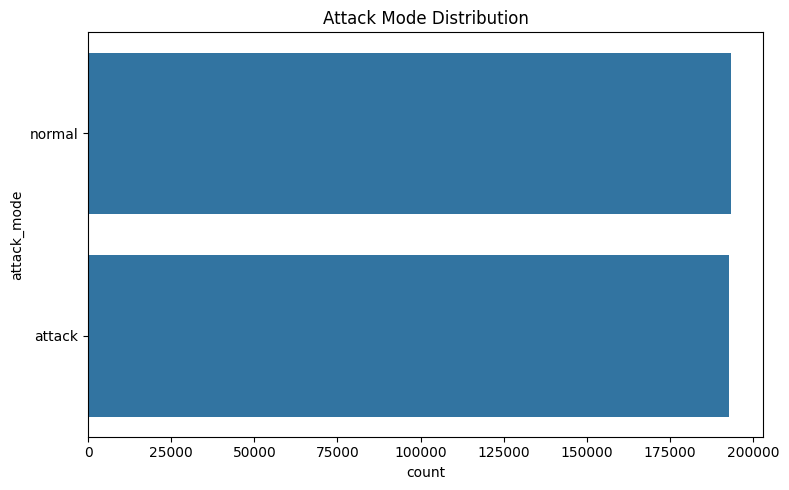

In [6]:
# --- 3. Perform Data Visualization (Initial) ---
print("\n--- Initial Data Visualization ---")
plt.figure(figsize=(8, 5))
sns.countplot(y='attack_mode', data=df, order = df['attack_mode'].value_counts().index)
plt.title('Attack Mode Distribution')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_PATH, "attack_mode_distribution.png"))
plt.show()


--- Data Preprocessing ---

Processed Label Distribution:
 label
0    193374
1    192898
Name: count, dtype: int64


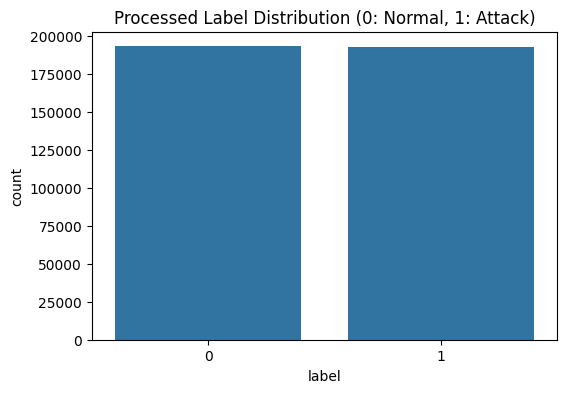

Number of candidate numerical features: 235

Missing values before imputation: 0
Missing values after imputation: 0


['trained_models_csv/scaler.joblib']

In [7]:
# --- Data Preprocessing ---
print("\n--- Data Preprocessing ---")

# Label Encoding for 'attack_mode' -> 'label' (0 for normal, 1 for attack)
# Modify this based on your 'attack_mode' values
df['label'] = df['attack_mode'].apply(lambda x: 0 if str(x).lower() == 'normal' else 1)
print("\nProcessed Label Distribution:\n", df['label'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Processed Label Distribution (0: Normal, 1: Attack)')
plt.savefig(os.path.join(MODEL_SAVE_PATH, "processed_label_distribution.png"))
plt.show()

# Feature Selection: Identify numerical features
# Drop identifiers, time, original attack columns, and any other non-numeric/non-predictive columns
cols_to_drop = ['start_time', 'end_time', 'attack_mode', 'attack_sublabel', 'attack_phase']
# Check if columns exist before dropping
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df_features = df.drop(columns=existing_cols_to_drop)

# Separate features (X) and target (y)
y = df['label']
X_numerical_candidate = df_features.select_dtypes(include=np.number)

# Ensure 'label' is not in X
if 'label' in X_numerical_candidate.columns:
    X_numerical_candidate = X_numerical_candidate.drop(columns=['label'])

print(f"Number of candidate numerical features: {X_numerical_candidate.shape[1]}")
original_feature_names = X_numerical_candidate.columns.tolist()

# Handle Missing Values (Imputation)
print(f"\nMissing values before imputation: {X_numerical_candidate.isnull().sum().sum()}")
imputer = SimpleImputer(strategy='mean') # Or 'median', 'most_frequent'
X_imputed = imputer.fit_transform(X_numerical_candidate)
X_imputed_df = pd.DataFrame(X_imputed, columns=original_feature_names)
print(f"Missing values after imputation: {X_imputed_df.isnull().sum().sum()}")
joblib.dump(imputer, os.path.join(MODEL_SAVE_PATH, "imputer.joblib"))

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed_df)
X_scaled_df = pd.DataFrame(X_scaled, columns=original_feature_names)
joblib.dump(scaler, os.path.join(MODEL_SAVE_PATH, "scaler.joblib"))

In [8]:
# --- 4. Add Noise (Optional - If data is too well classified) ---
# This step is highly subjective and might not always be beneficial.
# For this structured data, if you add noise, add it to X_scaled.
# Example:
noise_level = 0.05
noise = np.random.normal(0, noise_level, X_scaled.shape)
X_processed = X_scaled + noise
print("\nNoise added to scaled features.")
X_processed = X_scaled # No noise added in this run


Noise added to scaled features.



--- Feature Selection & Dimensionality Reduction ---
Selecting top 50 features using SelectKBest.
Selected features (50):
 ['mmap_mean', 'mmap_max', 'munmap_mean', 'munmap_max', 'brk_mean', 'brk_max', 'bind_mean', 'bind_max', 'chdir_mean', 'chdir_max']...


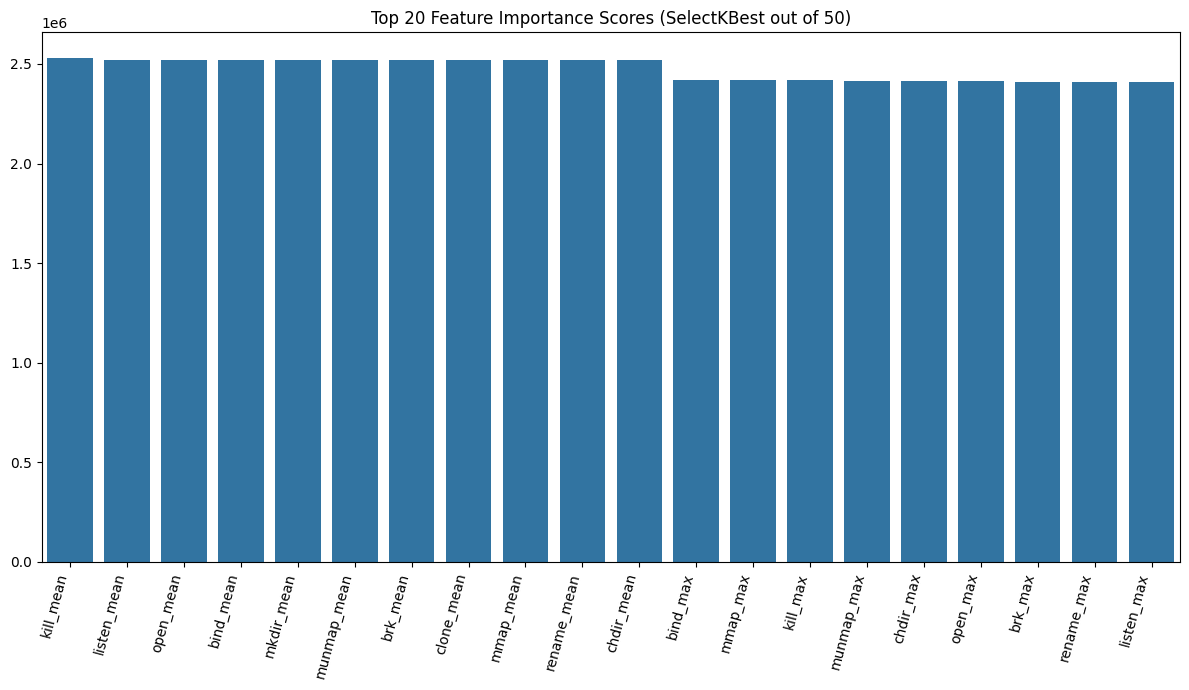


Applying PCA...
Shape after PCA: (386272, 2) (original selected: (386272, 50))


['trained_models_csv/pca_transformer.joblib']

In [9]:
# --- 5. Perform Feature Selection and Dimensionality Reduction ---
print("\n--- Feature Selection & Dimensionality Reduction ---")

# Feature Selection (SelectKBest)
num_features_to_select = min(50, X_processed.shape[1]) # Select top 50 features or all if less
print(f"Selecting top {num_features_to_select} features using SelectKBest.")
selector = SelectKBest(score_func=f_classif, k=num_features_to_select)
X_selected = selector.fit_transform(X_processed, y)
selected_indices = selector.get_support(indices=True)
selected_features_names = X_imputed_df.columns[selected_indices].tolist()
print(f"Selected features ({len(selected_features_names)}):\n {selected_features_names[:10]}...") # Print first 10
joblib.dump(selector, os.path.join(MODEL_SAVE_PATH, "feature_selector.joblib"))
joblib.dump(selected_features_names, os.path.join(MODEL_SAVE_PATH, "selected_features_names.joblib")) # Save names for inference

# Visualization of selected feature scores
plt.figure(figsize=(12, 7))
scores = selector.scores_[selected_indices]
# Sort features by score for better visualization
sorted_indices_for_plot = np.argsort(scores)[::-1]
sns.barplot(x=np.array(selected_features_names)[sorted_indices_for_plot][:20], y=scores[sorted_indices_for_plot][:20]) # Plot top 20
plt.title(f'Top 20 Feature Importance Scores (SelectKBest out of {len(selected_features_names)})')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_PATH, "feature_importance_selected.png"))
plt.show()

# Dimensionality Reduction (PCA) - Applied on SELECTED features
# Or you could apply PCA on all X_processed features directly
print("\nApplying PCA...")
pca = PCA(n_components=0.95, random_state=RANDOM_STATE) # Keep 95% of variance
X_pca = pca.fit_transform(X_selected)
print(f"Shape after PCA: {X_pca.shape} (original selected: {X_selected.shape})")
joblib.dump(pca, os.path.join(MODEL_SAVE_PATH, "pca_transformer.joblib"))


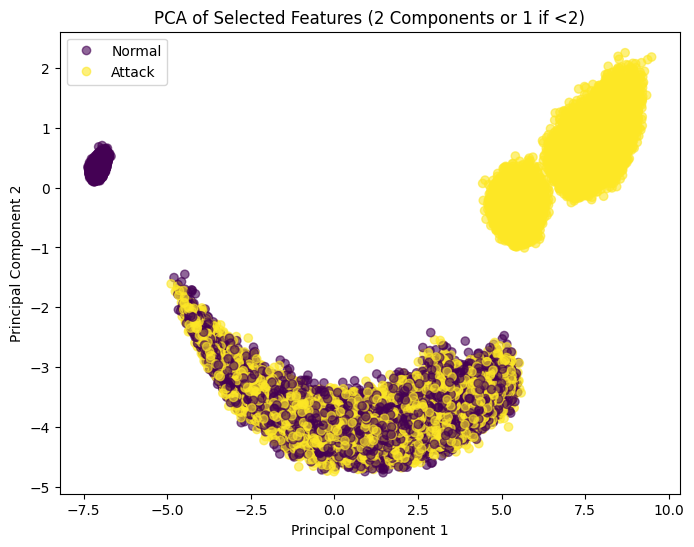

Shape for ML models: (386272, 50)
Shape for LSTM/GRU models: (386272, 50, 1)
Shape for DNN model: (386272, 50)


In [10]:
# --- 6. Visualization at each step (PCA example) ---
plt.figure(figsize=(8, 6))
if X_pca.shape[1] >= 2:
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(handles=scatter.legend_elements()[0], labels=['Normal', 'Attack'])
else: # Handle cases where PCA results in < 2 components
    plt.hist(X_pca[:,0], bins=50, color='skyblue')
    plt.xlabel('Principal Component 1')
plt.title('PCA of Selected Features (2 Components or 1 if <2)')
plt.savefig(os.path.join(MODEL_SAVE_PATH, "pca_visualization.png"))
plt.show()

# Final features for ML models (you can choose X_selected or X_pca)
# Using X_selected for now as it preserves some feature interpretability
X_for_ml_final = X_selected
# X_for_ml_final = X_pca # If you prefer PCA-transformed features

# --- Data for DL models ---
# For LSTM/GRU, we'll reshape X_selected (or X_processed if not selecting)
# Each row's features are treated as a sequence.
# Input shape: (n_samples, n_features_selected, 1)
X_for_dl_final = X_selected.reshape((X_selected.shape[0], X_selected.shape[1], 1))
# For Dense NN (MLP), we can use X_selected directly (2D)
X_for_dnn_final = X_selected

print(f"Shape for ML models: {X_for_ml_final.shape}")
print(f"Shape for LSTM/GRU models: {X_for_dl_final.shape}")
print(f"Shape for DNN model: {X_for_dnn_final.shape}")

In [11]:
# --- 7. Split data into train, validation, and test ---
print("\n--- Splitting Data ---")
# Stratify by 'y' to maintain class proportions.
# X_for_ml_final is likely a NumPy array here (output of SelectKBest or PCA)
# y is a Pandas Series.

X_train_ml, X_temp_ml, y_train_series, y_temp_series = train_test_split(
    X_for_ml_final, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
# y_train_series, y_temp_series are Pandas Series and retain original indices

X_val_ml, X_test_ml, y_val_series, y_test_series = train_test_split(
    X_temp_ml, y_temp_series, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp_series
)
# y_val_series, y_test_series are Pandas Series and retain original indices

# Now, get the indices from these y_..._series to slice X_for_dl_final and X_for_dnn_final
# X_for_dl_final and X_for_dnn_final are NumPy arrays derived from X_selected,
# so they are aligned with the original 'y' Series by row number before shuffling.
# We use the indices from the y splits to ensure we get the corresponding rows
# from the *original unsplit* X_for_dl_final and X_for_dnn_final.

train_indices = y_train_series.index
val_indices = y_val_series.index
test_indices = y_test_series.index

# X_for_dl_final and X_for_dnn_final were created based on X_selected, which had the same
# number of rows as y, and in the same original order before train_test_split.
# So, we can use these indices directly on X_for_dl_final and X_for_dnn_final.
X_train_dl = X_for_dl_final[train_indices]
X_val_dl = X_for_dl_final[val_indices]
X_test_dl = X_for_dl_final[test_indices]

X_train_dnn = X_for_dnn_final[train_indices]
X_val_dnn = X_for_dnn_final[val_indices]
X_test_dnn = X_for_dnn_final[test_indices]

# Convert y_..._series to numpy arrays for Keras/sklearn model training
y_train_np = y_train_series.values
y_val_np = y_val_series.values
y_test_np = y_test_series.values


print("ML Data shapes (Train, Val, Test): ", X_train_ml.shape, X_val_ml.shape, X_test_ml.shape)
print("LSTM/GRU Data shapes (Train, Val, Test): ", X_train_dl.shape, X_val_dl.shape, X_test_dl.shape)
print("DNN Data shapes (Train, Val, Test): ", X_train_dnn.shape, X_val_dnn.shape, X_test_dnn.shape)
print("Target shapes (Train, Val, Test): ", y_train_np.shape, y_val_np.shape, y_test_np.shape)

# Sanity check: make sure the number of samples match
assert X_train_ml.shape[0] == y_train_np.shape[0] == X_train_dl.shape[0] == X_train_dnn.shape[0]
assert X_val_ml.shape[0] == y_val_np.shape[0] == X_val_dl.shape[0] == X_val_dnn.shape[0]
assert X_test_ml.shape[0] == y_test_np.shape[0] == X_test_dl.shape[0] == X_test_dnn.shape[0]


--- Splitting Data ---
ML Data shapes (Train, Val, Test):  (270390, 50) (57941, 50) (57941, 50)
LSTM/GRU Data shapes (Train, Val, Test):  (270390, 50, 1) (57941, 50, 1) (57941, 50, 1)
DNN Data shapes (Train, Val, Test):  (270390, 50) (57941, 50) (57941, 50)
Target shapes (Train, Val, Test):  (270390,) (57941,) (57941,)


In [14]:
# --- 8. Train Models ---
print("\n--- Model Training ---")
results = {}
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# --- Random Forest ---
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced')
rf_model.fit(X_train_ml, y_train_np)
joblib.dump(rf_model, os.path.join(MODEL_SAVE_PATH, "random_forest_model.joblib"))
print("Random Forest training complete.")



# --- SVM ---
print("\nTraining LinearSVC (optimized for linear SVM)...")
# LinearSVC is generally faster for large datasets if a linear model is acceptable
linear_svm_model = LinearSVC(random_state=RANDOM_STATE, class_weight='balanced', dual="auto", max_iter=10000) # dual="auto" is often a good choice
linear_svm_model.fit(X_train_ml, y_train_np)

# If you need probabilities from LinearSVC:
print("Calibrating LinearSVC for probabilities...")
svm_model = CalibratedClassifierCV(linear_svm_model, method='isotonic', cv=3) # Or method='sigmoid'
svm_model.fit(X_train_ml, y_train_np) # Calibrate on the training data

joblib.dump(svm_model, os.path.join(MODEL_SAVE_PATH, "svm_model.joblib")) # Save the calibrated model
print("LinearSVC (calibrated) training complete.")

# --- Dense Neural Network (MLP) ---
print("\nTraining DNN (MLP)...")
INPUT_SHAPE_DNN = (X_train_dnn.shape[1],)
dnn_model = Sequential([
    Input(shape=INPUT_SHAPE_DNN),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.summary()
history_dnn = dnn_model.fit(X_train_dnn, y_train_np,
                            epochs=50, # More epochs for DNN typically
                            batch_size=64,
                            validation_data=(X_val_dnn, y_val_np),
                            callbacks=[early_stopping],
                            verbose=1)
dnn_model.save(os.path.join(MODEL_SAVE_PATH, "dnn_model.keras"))
print("DNN training complete.")


# --- LSTM ---
# Input shape for LSTM: (n_samples, timesteps=n_features_selected, features_per_timestep=1)
print("\nTraining LSTM...")
INPUT_SHAPE_LSTM = (X_train_dl.shape[1], X_train_dl.shape[2]) # (num_features_selected, 1)
LSTM_UNITS = 64

lstm_model = Sequential([
    Input(shape=INPUT_SHAPE_LSTM),
    LSTM(LSTM_UNITS, return_sequences=True), # return_sequences=True if another LSTM/GRU follows
    Dropout(0.3),
    LSTM(LSTM_UNITS // 2), # Last LSTM layer before Dense
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()
history_lstm = lstm_model.fit(X_train_dl, y_train_np,
                              epochs=30, # Adjust epochs
                              batch_size=64,
                              validation_data=(X_val_dl, y_val_np),
                              callbacks=[early_stopping],
                              verbose=1)
lstm_model.save(os.path.join(MODEL_SAVE_PATH, "lstm_model.keras"))
print("LSTM training complete.")

# --- GRU ---
print("\nTraining GRU...")
GRU_UNITS = 64
gru_model = Sequential([
    Input(shape=INPUT_SHAPE_LSTM), # Same input shape as LSTM
    GRU(GRU_UNITS, return_sequences=True),
    Dropout(0.3),
    GRU(GRU_UNITS // 2),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gru_model.summary()
history_gru = gru_model.fit(X_train_dl, y_train_np,
                            epochs=30, # Adjust epochs
                            batch_size=64,
                            validation_data=(X_val_dl, y_val_np),
                            callbacks=[early_stopping],
                            verbose=1)
gru_model.save(os.path.join(MODEL_SAVE_PATH, "gru_model.keras"))
print("GRU training complete.")


--- Model Training ---

Training Random Forest...
Random Forest training complete.

Training LinearSVC (optimized for linear SVM)...
Calibrating LinearSVC for probabilities...
LinearSVC (calibrated) training complete.

Training DNN (MLP)...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,849 (58.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,361 (91.25 KB)

 Trainable params: 23,361 (91.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
4225/4225 ━━━━━━━━━━━━━━━━━━━━ 364s 85ms/step - accuracy: 0.9619 - loss: 0.0722 - val_accuracy: 0.9626 - val_loss: 0.0509
Epoch 2/30
4225/4225 ━━━━━━━━━━━━━━━━━━━━ 361s 86ms/step - accuracy: 0.9623 - loss: 0.0528 - val_accuracy: 0.9626 - val_loss: 0.0509
Epoch 3/30
4225/4225 ━━━━━━━━━━━━━━━━━━━━ 380s 85ms/step - accuracy: 0.9622 - loss: 0.0555 - val_accuracy: 0.9626 - val_loss: 0.0509
Epoch 4/30
4225/4225 ━━━━━━━━━━━━━━━━━━━━ 382s 85ms/step - accuracy: 0.9623 - loss: 0.0523 - val_accuracy: 0.9626 - val_loss: 0.0510
Epoch 5/30
4225/4225 ━━━━━━━━━━━━━━━━━━━━ 380s 85ms/step - accuracy: 0.9624 - loss: 0.0525 - val_accuracy: 0.9626 - val_loss: 0.0509
Epoch 6/30
4225/4225 ━━━━━━━━━━━━━━━━━━━━ 376s 83ms/step - accuracy: 0.9624 - loss: 0.0523 - val_accuracy: 0.9626 - val_loss: 0.0509
Epoch 7/30
4225/4225 ━━━━━━━━━━━━━━━━━━━━ 361s 85ms/step - accuracy: 0.9624 - loss: 0.0523 - val_accuracy: 0.9626 - val_loss: 0.0509
Epoch 8/30
4225/4225 ━━━━━━━━━━━━━━━━━━━━ 376s 84ms/step - accuracy: 


--- Model Evaluation ---

Evaluating Random Forest:
Accuracy: 0.9634
Precision: 0.9666
Recall: 0.9599
F1-score: 0.9632
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96     29006
           1       0.97      0.96      0.96     28935

    accuracy                           0.96     57941
   macro avg       0.96      0.96      0.96     57941
weighted avg       0.96      0.96      0.96     57941



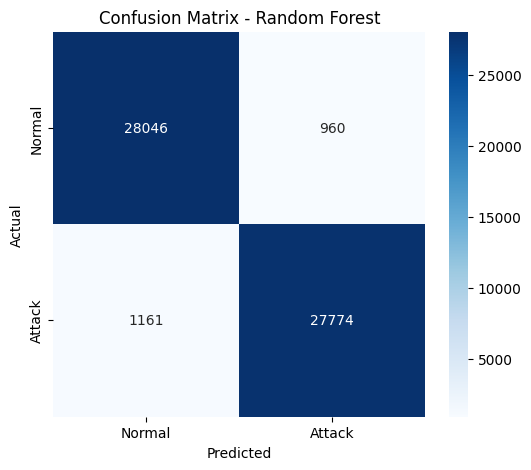


Evaluating SVM:
Accuracy: 0.9631
Precision: 0.9865
Recall: 0.9389
F1-score: 0.9621
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96     29006
           1       0.99      0.94      0.96     28935

    accuracy                           0.96     57941
   macro avg       0.96      0.96      0.96     57941
weighted avg       0.96      0.96      0.96     57941



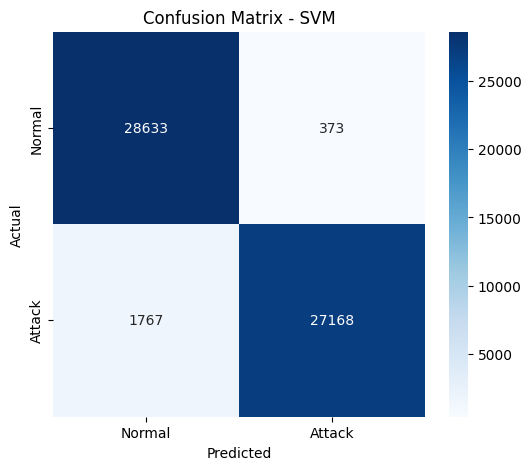


Evaluating DNN (MLP):
Accuracy: 0.9638
Precision: 0.9943
Recall: 0.9328
F1-score: 0.9626
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96     29006
           1       0.99      0.93      0.96     28935

    accuracy                           0.96     57941
   macro avg       0.97      0.96      0.96     57941
weighted avg       0.97      0.96      0.96     57941



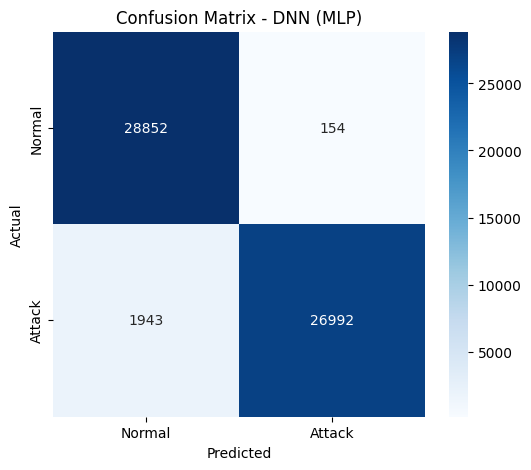


Evaluating LSTM:
Accuracy: 0.9639
Precision: 1.0000
Recall: 0.9278
F1-score: 0.9625
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97     29006
           1       1.00      0.93      0.96     28935

    accuracy                           0.96     57941
   macro avg       0.97      0.96      0.96     57941
weighted avg       0.97      0.96      0.96     57941



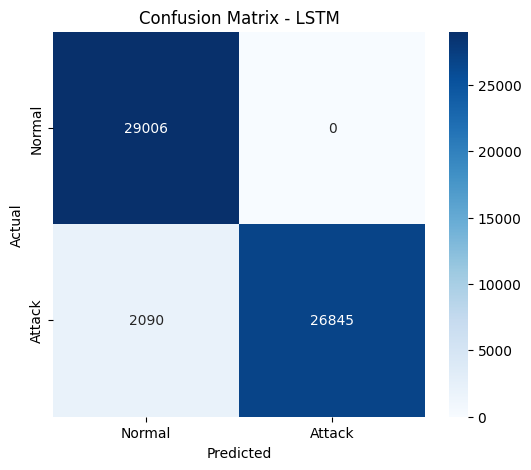


Evaluating GRU:
Accuracy: 0.9639
Precision: 1.0000
Recall: 0.9278
F1-score: 0.9625
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97     29006
           1       1.00      0.93      0.96     28935

    accuracy                           0.96     57941
   macro avg       0.97      0.96      0.96     57941
weighted avg       0.97      0.96      0.96     57941



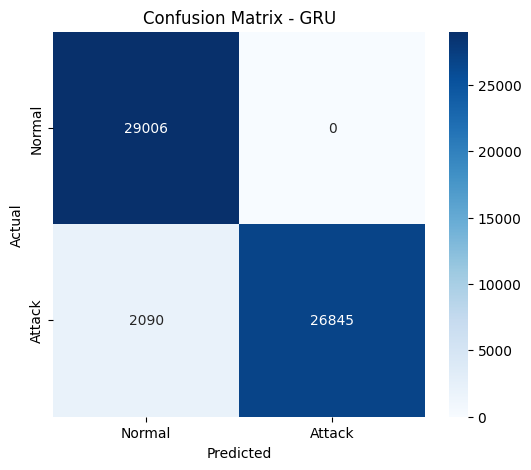

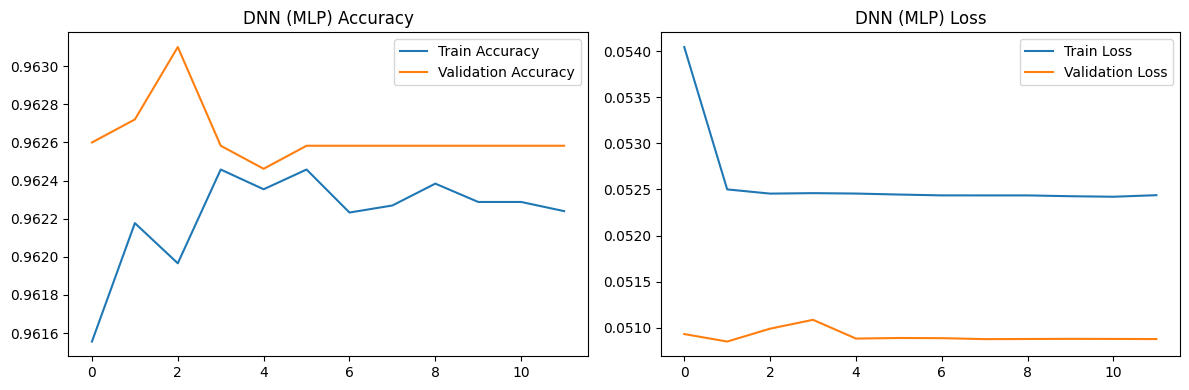

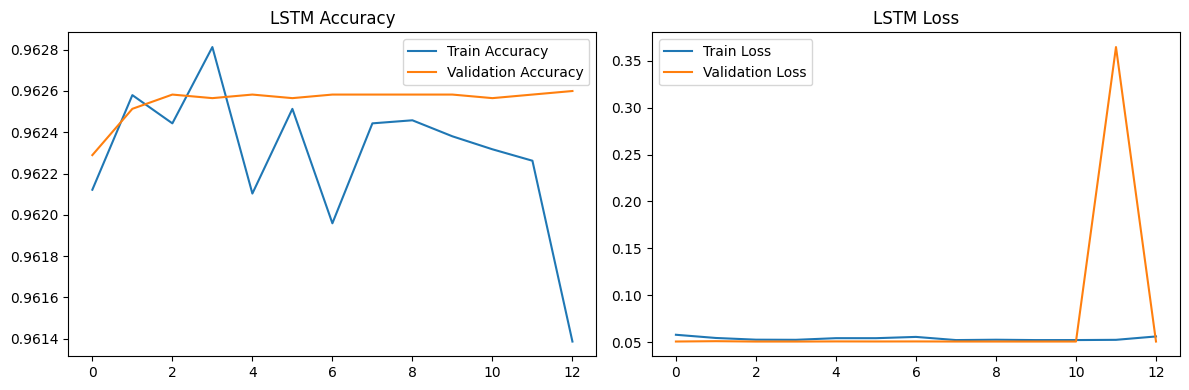

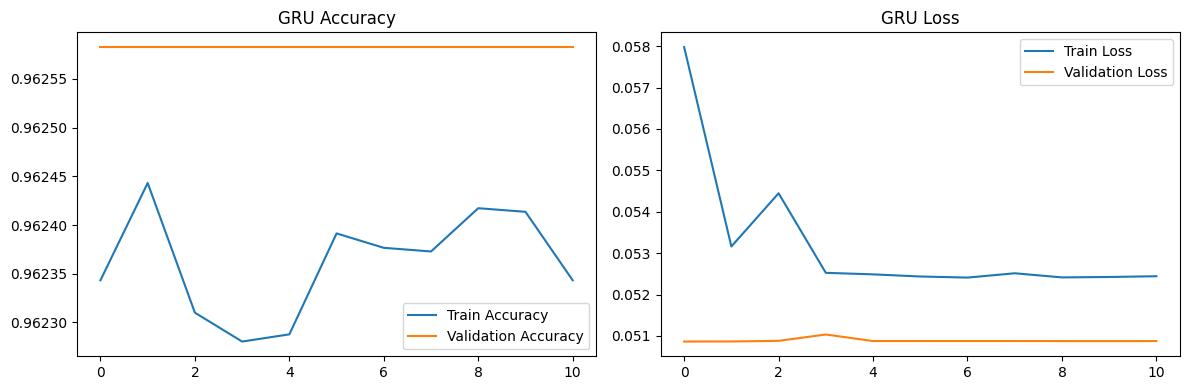


Evaluation Results Summary:

--- Random Forest ---
Accuracy: 0.9634
Precision: 0.9666
Recall: 0.9599
F1: 0.9632

--- SVM ---
Accuracy: 0.9631
Precision: 0.9865
Recall: 0.9389
F1: 0.9621

--- DNN ---
Accuracy: 0.9638
Precision: 0.9943
Recall: 0.9328
F1: 0.9626

--- LSTM ---
Accuracy: 0.9639
Precision: 1.0000
Recall: 0.9278
F1: 0.9625

--- GRU ---
Accuracy: 0.9639
Precision: 1.0000
Recall: 0.9278
F1: 0.9625


In [15]:
# --- 9. Save Model (already done during training) ---

# --- 10. Perform Evaluation & Construct Confusion Matrix ---
print("\n--- Model Evaluation ---")

def evaluate_model(model_path, X_test_data, y_test_data, model_name, is_dl_model=False, threshold=0.5):
    print(f"\nEvaluating {model_name}:")
    if is_dl_model:
        model = load_model(model_path)
        y_pred_proba = model.predict(X_test_data, verbose=0)
        y_pred = (y_pred_proba > threshold).astype(int).flatten()
    else:
        model = joblib.load(model_path)
        y_pred_proba = model.predict_proba(X_test_data)[:, 1] # Prob of positive class
        y_pred = model.predict(X_test_data)

    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred, zero_division=0)
    recall = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Classification Report:\n", classification_report(y_test_data, y_pred, zero_division=0))

    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.savefig(os.path.join(MODEL_SAVE_PATH, f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png"))
    plt.show()
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

results['Random Forest'] = evaluate_model(os.path.join(MODEL_SAVE_PATH, "random_forest_model.joblib"), X_test_ml, y_test_np, "Random Forest")
results['SVM'] = evaluate_model(os.path.join(MODEL_SAVE_PATH, "svm_model.joblib"), X_test_ml, y_test_np, "SVM")
results['DNN'] = evaluate_model(os.path.join(MODEL_SAVE_PATH, "dnn_model.keras"), X_test_dnn, y_test_np, "DNN (MLP)", is_dl_model=True)
results['LSTM'] = evaluate_model(os.path.join(MODEL_SAVE_PATH, "lstm_model.keras"), X_test_dl, y_test_np, "LSTM", is_dl_model=True)
results['GRU'] = evaluate_model(os.path.join(MODEL_SAVE_PATH, "gru_model.keras"), X_test_dl, y_test_np, "GRU", is_dl_model=True)

def plot_dl_history(history, model_name):
    if history is None or not hasattr(history, 'history'):
        print(f"No training history available for {model_name}.")
        return
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_PATH, f"training_history_{model_name.lower().replace(' (mlp)','').replace(' ','_')}.png"))
    plt.show()

plot_dl_history(history_dnn if 'history_dnn' in locals() else None, "DNN (MLP)")
plot_dl_history(history_lstm if 'history_lstm' in locals() else None, "LSTM")
plot_dl_history(history_gru if 'history_gru' in locals() else None, "GRU")

print("\nEvaluation Results Summary:")
for model_name, metrics_dict in results.items():
    print(f"\n--- {model_name} ---")
    for metric, value in metrics_dict.items():
        print(f"{metric.capitalize()}: {value:.4f}")

In [16]:
from google.colab import files
import os # Make sure os is imported

# Example: Assuming your models are saved in MODEL_SAVE_PATH
MODEL_SAVE_PATH = "trained_models_csv" # Or whatever your path is

# --- Download Random Forest Model ---
rf_model_path = os.path.join(MODEL_SAVE_PATH, "random_forest_model.joblib")
if os.path.exists(rf_model_path):
    print(f"Downloading {rf_model_path}...")
    files.download(rf_model_path)
else:
    print(f"File not found: {rf_model_path}")

# --- Download SVM Model ---
svm_model_path = os.path.join(MODEL_SAVE_PATH, "svm_model.joblib")
if os.path.exists(svm_model_path):
    print(f"Downloading {svm_model_path}...")
    files.download(svm_model_path)
else:
    print(f"File not found: {svm_model_path}")

# --- Download DNN Model ---
dnn_model_path = os.path.join(MODEL_SAVE_PATH, "dnn_model.keras")
if os.path.exists(dnn_model_path):
    print(f"Downloading {dnn_model_path}...")
    files.download(dnn_model_path)
else:
    print(f"File not found: {dnn_model_path}")

# --- Download LSTM Model ---
lstm_model_path = os.path.join(MODEL_SAVE_PATH, "lstm_model.keras")
if os.path.exists(lstm_model_path):
    print(f"Downloading {lstm_model_path}...")
    files.download(lstm_model_path)
else:
    print(f"File not found: {lstm_model_path}")

# --- Download GRU Model ---
gru_model_path = os.path.join(MODEL_SAVE_PATH, "gru_model.keras")
if os.path.exists(gru_model_path):
    print(f"Downloading {gru_model_path}...")
    files.download(gru_model_path)
else:
    print(f"File not found: {gru_model_path}")

# --- Download Preprocessors ---
imputer_path = os.path.join(MODEL_SAVE_PATH, "imputer.joblib")
if os.path.exists(imputer_path):
    print(f"Downloading {imputer_path}...")
    files.download(imputer_path)

scaler_path = os.path.join(MODEL_SAVE_PATH, "scaler.joblib")
if os.path.exists(scaler_path):
    print(f"Downloading {scaler_path}...")
    files.download(scaler_path)

selector_path = os.path.join(MODEL_SAVE_PATH, "feature_selector.joblib")
if os.path.exists(selector_path):
    print(f"Downloading {selector_path}...")
    files.download(selector_path)

selected_features_names_path = os.path.join(MODEL_SAVE_PATH, "selected_features_names.joblib")
if os.path.exists(selected_features_names_path):
    print(f"Downloading {selected_features_names_path}...")
    files.download(selected_features_names_path)

# ... and so on for any other files like pca_transformer.joblib, nystroem_transformer.joblib etc.
pca_transformer_path = os.path.join(MODEL_SAVE_PATH, "pca_transformer.joblib")
if os.path.exists(pca_transformer_path):
    print(f"Downloading {pca_transformer_path}...")
    files.download(pca_transformer_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# --- 11. Integrate Trained Models to Detect Anomaly on "Real-time" Data ---
print("\n--- Real-time Anomaly Detection Simulation ---")

# Load all necessary preprocessors and models
try:
    loaded_imputer = joblib.load(os.path.join(MODEL_SAVE_PATH, "imputer.joblib"))
    loaded_scaler = joblib.load(os.path.join(MODEL_SAVE_PATH, "scaler.joblib"))
    loaded_selector = joblib.load(os.path.join(MODEL_SAVE_PATH, "feature_selector.joblib"))
    # loaded_pca = joblib.load(os.path.join(MODEL_SAVE_PATH, "pca_transformer.joblib"))

    loaded_rf_model = joblib.load(os.path.join(MODEL_SAVE_PATH, "random_forest_model.joblib"))
    try:
        loaded_svm_model = joblib.load(os.path.join(MODEL_SAVE_PATH, "svm_model.joblib"))
        print("SVM model loaded successfully.")
    except FileNotFoundError:
        print("WARNING: svm_model.joblib not found. SVM predictions will be skipped.")
        loaded_svm_model = None # Ensure it's None if not loaded
    except Exception as e:
        print(f"WARNING: Error loading svm_model.joblib: {e}. SVM predictions will be skipped.")
        loaded_svm_model = None


    loaded_dnn_model = load_model(os.path.join(MODEL_SAVE_PATH, "dnn_model.keras"))
    loaded_lstm_model = load_model(os.path.join(MODEL_SAVE_PATH, "lstm_model.keras"))
    loaded_gru_model = load_model(os.path.join(MODEL_SAVE_PATH, "gru_model.keras"))
except Exception as e:
    print(f"FATAL: Could not load one or more models/preprocessors. Error: {e}")
    print("Real-time simulation cannot proceed.")
    # exit() # Or handle more gracefully

# original_feature_names should be available from the preprocessing steps.
# If running cells out of order, ensure it's defined.
if 'original_feature_names' not in locals() or not original_feature_names:
    print("ERROR: 'original_feature_names' is not defined or is empty. This is crucial for preprocessing.")
    print("Attempting to load from saved file (if you saved it during preprocessing)...")
    try:
        original_feature_names = joblib.load(os.path.join(MODEL_SAVE_PATH, "original_feature_names.joblib"))
        print("'original_feature_names' loaded from file.")
    except FileNotFoundError:
        print("FATAL: 'original_feature_names.joblib' not found. Cannot proceed with real-time simulation.")
        original_feature_names = [] # To prevent further errors but indicates a setup issue
    except Exception as e:
        print(f"FATAL: Error loading 'original_feature_names.joblib': {e}")
        original_feature_names = []


def preprocess_single_realtime_sample(raw_sample_dict, imputer_rt, scaler_rt, selector_rt, original_cols_order_list):
    # (Using original_cols_order_list to avoid conflict with any outer scope variable)
    if not original_cols_order_list:
        raise ValueError("original_cols_order_list cannot be empty for preprocessing.")

    sample_df = pd.DataFrame([raw_sample_dict])
    for col in original_cols_order_list:
        if col not in sample_df.columns:
            sample_df[col] = np.nan
    sample_df = sample_df[original_cols_order_list]

    imputed_values = imputer_rt.transform(sample_df) # Input is DF, output is np.array
    # Scaler expects a 2D array.
    scaled_values = scaler_rt.transform(imputed_values) # Input is np.array, output is np.array
    # Selector expects a 2D array.
    selected_sample_ml_numpy = selector_rt.transform(scaled_values) # Input is np.array, output is np.array

    selected_sample_dl_numpy = selected_sample_ml_numpy.reshape((selected_sample_ml_numpy.shape[0], selected_sample_ml_numpy.shape[1], 1))
    return selected_sample_ml_numpy, selected_sample_dl_numpy


def detect_anomaly_real_time_csv(raw_metrics_dict, current_original_feature_names):
    # (Using current_original_feature_names to avoid conflict)
    print(f"\n--- New Real-time Sample (CSV based) ---")
    if not current_original_feature_names:
        print("ERROR: original_feature_names_list is empty in detect_anomaly_real_time_csv. Cannot preprocess sample.")
        return

    try:
        ml_input, dl_input = preprocess_single_realtime_sample(
            raw_metrics_dict,
            loaded_imputer,
            loaded_scaler,
            loaded_selector,
            current_original_feature_names
        )

        # ML Model Predictions
        rf_pred_proba = loaded_rf_model.predict_proba(ml_input)[0, 1]
        rf_pred = loaded_rf_model.predict(ml_input)[0]
        print(f"RF Prediction: {'Attack' if rf_pred == 1 else 'Normal'} (Prob: {rf_pred_proba:.4f})")

        if loaded_svm_model is not None: # Check if SVM model was successfully loaded
            try:
                if hasattr(loaded_svm_model, 'predict_proba'):
                    svm_pred_proba = loaded_svm_model.predict_proba(ml_input)[0, 1]
                    svm_pred = loaded_svm_model.predict(ml_input)[0] # Or (svm_pred_proba > 0.5).astype(int)
                    print(f"SVM Prediction: {'Attack' if svm_pred == 1 else 'Normal'} (Prob: {svm_pred_proba:.4f})")
                else: # Case for LinearSVC without calibration or SVC with probability=False
                    svm_pred = loaded_svm_model.predict(ml_input)[0]
                    print(f"SVM Prediction: {'Attack' if svm_pred == 1 else 'Normal'} (Prob: N/A)")
            except Exception as e:
                print(f"Error during SVM prediction: {e}")
        else:
            print("SVM Model not available for prediction.")

        # DL Model Predictions
        dnn_pred_proba = loaded_dnn_model.predict(ml_input, verbose=0)[0,0]
        dnn_pred = 1 if dnn_pred_proba > 0.5 else 0
        lstm_pred_proba = loaded_lstm_model.predict(dl_input, verbose=0)[0,0]
        lstm_pred = 1 if lstm_pred_proba > 0.5 else 0
        gru_pred_proba = loaded_gru_model.predict(dl_input, verbose=0)[0,0]
        gru_pred = 1 if gru_pred_proba > 0.5 else 0
        print(f"DNN Prediction: {'Attack' if dnn_pred == 1 else 'Normal'} (Prob: {dnn_pred_proba:.4f})")
        print(f"LSTM Prediction: {'Attack' if lstm_pred == 1 else 'Normal'} (Prob: {lstm_pred_proba:.4f})")
        print(f"GRU Prediction: {'Attack' if gru_pred == 1 else 'Normal'} (Prob: {gru_pred_proba:.4f})")

    except Exception as e:
        print(f"Error during real-time prediction pipeline: {e}")
        import traceback
        traceback.print_exc()


# Simulate a real-time sample
if 'df_original' in locals() and \
   'y_test_series' in locals() and len(y_test_series) > 0 and \
   'y_test_np' in locals() and len(y_test_np) > 0 and \
   'original_feature_names' in locals() and original_feature_names: # Ensure original_feature_names is not empty

    test_set_original_indices = y_test_series.index

    # --- NORMAL SAMPLE ---
    normal_indices_in_test = test_set_original_indices[y_test_np == 0]
    if len(normal_indices_in_test) > 0:
        normal_sample_orig_idx = normal_indices_in_test[0]
        print(f"\n--- Simulating NORMAL real-time sample (Original Index: {normal_sample_orig_idx}) ---")
        print(f"Original 'attack_mode' for this sample: {df_original.loc[normal_sample_orig_idx, 'attack_mode']}")
        raw_normal_sample_dict = df_original.loc[normal_sample_orig_idx, original_feature_names].to_dict()
        detect_anomaly_real_time_csv(raw_normal_sample_dict, original_feature_names)
    else:
        print("No normal samples found in the test set for simulation.")

    # --- ATTACK SAMPLE ---
    attack_indices_in_test = test_set_original_indices[y_test_np == 1]
    if len(attack_indices_in_test) > 0:
        attack_sample_orig_idx = attack_indices_in_test[0] # Taking the first one
        print(f"\n--- Simulating ATTACK real-time sample (Original Index: {attack_sample_orig_idx}) ---")
        print(f"Original 'attack_mode' for this sample: {df_original.loc[attack_sample_orig_idx, 'attack_mode']}")
        # You can print some feature values for this attack sample to inspect
        # print("Sample of feature values for this attack sample:")
        # print(df_original.loc[attack_sample_orig_idx, original_feature_names].head())

        raw_attack_sample_dict = df_original.loc[attack_sample_orig_idx, original_feature_names].to_dict()
        detect_anomaly_real_time_csv(raw_attack_sample_dict, original_feature_names)

        # --- TRY ANOTHER ATTACK SAMPLE if available ---
        if len(attack_indices_in_test) > 1:
            attack_sample_orig_idx_2 = attack_indices_in_test[1] # Taking the second one
            print(f"\n--- Simulating ANOTHER ATTACK real-time sample (Original Index: {attack_sample_orig_idx_2}) ---")
            print(f"Original 'attack_mode' for this sample: {df_original.loc[attack_sample_orig_idx_2, 'attack_mode']}")
            raw_attack_sample_dict_2 = df_original.loc[attack_sample_orig_idx_2, original_feature_names].to_dict()
            detect_anomaly_real_time_csv(raw_attack_sample_dict_2, original_feature_names)
    else:
        print("No attack samples found in the test set for simulation.")
else:
    print("\nSkipping real-time simulation due to missing necessary variables or empty test set / original_feature_names list.")
    if 'dummy_features' in locals() and 'original_feature_names' in locals() and original_feature_names:
        print("Attempting real-time simulation with DUMMY data (if applicable)...")
        dummy_real_time_sample = {name: random.random()*100 for name in original_feature_names}
        detect_anomaly_real_time_csv(dummy_real_time_sample, original_feature_names)

print("\n--- Script Finished ---")


--- Real-time Anomaly Detection Simulation ---
SVM model loaded successfully.

--- Simulating NORMAL real-time sample (Original Index: 74761) ---
Original 'attack_mode' for this sample: normal

--- New Real-time Sample (CSV based) ---
RF Prediction: Normal (Prob: 0.0000)
SVM Prediction: Normal (Prob: 0.0000)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


DNN Prediction: Normal (Prob: 0.0000)
LSTM Prediction: Normal (Prob: 0.0000)
GRU Prediction: Normal (Prob: 0.0000)

--- Simulating ATTACK real-time sample (Original Index: 281407) ---
Original 'attack_mode' for this sample: attack

--- New Real-time Sample (CSV based) ---
RF Prediction: Normal (Prob: 0.4700)
SVM Prediction: Normal (Prob: 0.4967)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


DNN Prediction: Normal (Prob: 0.4950)
LSTM Prediction: Normal (Prob: 0.4935)
GRU Prediction: Normal (Prob: 0.4952)

--- Simulating ANOTHER ATTACK real-time sample (Original Index: 185981) ---
Original 'attack_mode' for this sample: attack

--- New Real-time Sample (CSV based) ---
RF Prediction: Attack (Prob: 1.0000)
SVM Prediction: Attack (Prob: 1.0000)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


DNN Prediction: Attack (Prob: 1.0000)
LSTM Prediction: Attack (Prob: 1.0000)
GRU Prediction: Attack (Prob: 1.0000)

--- Script Finished ---
